In [1]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import math

import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [4]:
from utils.plot import show_heatmaps

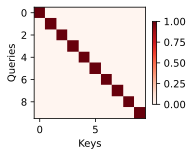

In [5]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

In [6]:
from utils.attention import masked_softmax

In [7]:
torch.manual_seed(42)
# B, N, M (num_batch, num_queries, num_keys/values)
X = torch.randn(2, 2, 4)
attention_matrix = masked_softmax(X, torch.tensor([2, 3]))
print(attention_matrix.shape)
# sets all the keys after valid_len equal to 0, 
# sum over keys is equal to 1
print(attention_matrix)

torch.Size([2, 2, 4])
tensor([[[0.6082, 0.3918, 0.0000, 0.0000],
         [0.8714, 0.1286, 0.0000, 0.0000]],

        [[0.0743, 0.8193, 0.1064, 0.0000],
         [0.3181, 0.3765, 0.3054, 0.0000]]])


In [8]:
# Normally, every output token sees every non-padded key/value pair.
# This means that valid_len is a 1D array of length (B). valid_len
# is identical for every query.
# 
# However, in the decoder self-attention, the tokens are masked
# with a causal structure. This means that query i can only see
# keys/values at position j \le i. So each query needs a different
# valid_len, to ensure causality.
#
# In other words, valid_len does not need to be identical for every
# query in a batch. 
# 
# In this example, valid_len is given by a causal mask. The i-th query
# can only see keys/values at j \le i.
X = torch.randn(2, 3, 3)
masked_softmax(X, torch.tensor([[1, 2, 3], [1, 2, 3]]))

tensor([[[1.0000, 0.0000, 0.0000],
         [0.8019, 0.1981, 0.0000],
         [0.4757, 0.1615, 0.3628]],

        [[1.0000, 0.0000, 0.0000],
         [0.0324, 0.9676, 0.0000],
         [0.1857, 0.0732, 0.7411]]])

In [9]:
from utils.attention import DotProductAttention

In [10]:
torch.manual_seed(42)
queries = torch.randn((2, 1, 2)) # B, N, D
keys = torch.randn((2, 10, 2)) # B, M, D
values = torch.randn((2, 10, 4)) # B, M, V
valid_lens = torch.tensor([2, 6]) # B

attention = DotProductAttention(dropout=0.5)
attention.train()
out = attention(queries, keys, values, valid_lens)
print(out.shape) # B, N, V
# None of the elements of DotProductAttention are zeroed out
# because even though keys/values greater than [2 or 6] are
# zeroed out, [2 or 6] length-4 values are summed which is 
# non-zero
print(out) 

torch.Size([2, 1, 4])
tensor([[[2.0737, 0.9295, 2.0033, 1.6074]],

        [[0.0607, 0.4198, 0.0560, 0.2489]]])


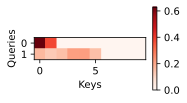

In [11]:
plt.close('all')
# the y-axis is the batch dimension, the x-axis is the keys
# only the first [2 or 6] keys are used in the attention
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

In [12]:
from utils.attention import AdditiveAttention

In [13]:
torch.manual_seed(42)
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(num_hiddens=8, dropout=0.1)
attention.eval()
print(attention(queries, keys, values, valid_lens))

tensor([[[0.8777, 0.3121, 0.5276, 0.9131]],

        [[0.0484, 0.4052, 0.0533, 0.3395]]], grad_fn=<BmmBackward0>)


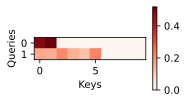

In [14]:
plt.close('all')
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### Bahdanau attention: Sequence-to-sequence translation

Define model

In [15]:
from utils.data import get_data_mt, build_mt
from utils.models import Seq2SeqEncoder, Seq2Seq, Decoder, init_seq2seq, Seq2SeqDecoder
from utils.train import fit_mt, loss_fn_mt

In [16]:
from utils.models import Seq2SeqAttentionDecoder

Test model on inputs

In [17]:
torch.manual_seed(42)
vocab_size, embed_size, num_hiddens, num_layers = 10, 8, 16, 2
batch_size, num_steps = 4, 7
encoder = Seq2SeqEncoder(vocab_size, embed_size, num_hiddens, num_layers)
decoder = Seq2SeqAttentionDecoder(vocab_size, embed_size, num_hiddens,
                                  num_layers)
X = torch.randint(0, vocab_size, (batch_size, num_steps), dtype=torch.long)
#print(X)
valid_len = torch.tensor([5,5,4,3])
enc_all_outputs = encoder(X)
state = decoder.init_state(enc_all_outputs, valid_len)
output, state = decoder(X, state)
print(f"output.shape = {output.shape}, expected = ({batch_size, num_steps, vocab_size})")
print(f"hidden state is {state[1].shape}")

output.shape = torch.Size([4, 7, 10]), expected = ((4, 7, 10))
hidden state is torch.Size([2, 4, 16])


Train model

In [18]:
batch_size, num_steps, num_train, num_val = 128, 9, 512, 128
embed_size, hidden_size, num_layers = 256, 256, 2
dropout, lr = 0.2, 0.005
num_epochs = 30

In [19]:
torch.manual_seed(0)
train_dl, val_dl, src_vocab, tgt_vocab = get_data_mt(batch_size, num_steps, num_train, num_val)
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, hidden_size, num_layers, dropout=dropout)
decoder = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size, hidden_size, num_layers, dropout=dropout)
model = Seq2Seq(encoder, decoder, tgt_vocab['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = lambda Y_hat, Y: loss_fn_mt(model, Y_hat, Y)

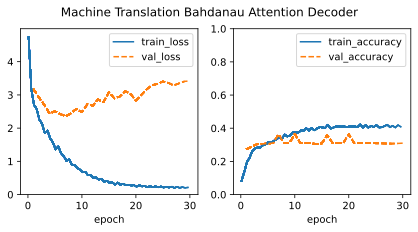

In [20]:
model = fit_mt(train_dl, val_dl, model, optimizer, loss_fn, num_epochs, 
       id="Machine Translation Bahdanau Attention Decoder", device=device);

#### Unroll model predictions

In [21]:
for batch in val_dl:
    outputs, _ = model.to('cpu').predict_step(batch, num_steps)
    print(outputs.shape)
    break

torch.Size([128, 9])


#### Make BLEU Predictions

In [22]:
from utils.metrics import bleu

In [23]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
arrays = build_mt(engs, fras, src_vocab, tgt_vocab)
preds, _ = model.predict_step(arrays, num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu: '
        f'{bleu(" ".join(translation), fr, k=2):.3f} '
        f'Target: {fr}')

go . => ['va', '!'], bleu: 1.000 Target: va !
i lost . => ["j'ai", 'perdu', '.'], bleu: 1.000 Target: j'ai perdu .
he's calm . => ['il', 'court', '.'], bleu: 0.000 Target: il est calme .
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu: 1.000 Target: je suis chez moi .


# Multi-Head Attention

In [24]:
from utils.attention import MultiHeadAttention

In [25]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_heads, 0.2)
batch_size, num_queries, num_kvpairs = 2, 4, 6
valid_lens = torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
print(attention(X, Y, Y, valid_lens).shape)


torch.Size([2, 4, 100])


# Self-Attention

In [26]:
num_hiddens, num_heads = 100, 5
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
attention = MultiHeadAttention(num_hiddens, num_heads, 0.2)
X = torch.ones((batch_size, num_queries, num_hiddens))
print(attention(X, X, X, valid_lens).shape)

torch.Size([2, 4, 100])


# Positional Encoding

In [27]:
from utils.attention import PositionalEncoding

In [28]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
P = pos_encoding.P[:, :num_steps, :]

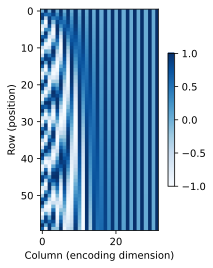

In [29]:
plt.close('all')
show_heatmaps(P.unsqueeze(1), xlabel='Column (encoding dimension)', ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')

# Transformer Architecture

#### Positionwise Feed-Forward Networks

In [30]:
from utils.attention import PositionWiseFFN

In [31]:
ffn = PositionWiseFFN(4, 8)
ffn.eval()
X = ffn(torch.ones((2,3,4)))
print(X.shape)
print(X[0])

torch.Size([2, 3, 8])
tensor([[-0.2578, -0.0631,  0.7304,  0.7365, -0.3140, -0.7612, -0.0245,  0.0302],
        [-0.2578, -0.0631,  0.7304,  0.7365, -0.3140, -0.7612, -0.0245,  0.0302],
        [-0.2578, -0.0631,  0.7304,  0.7365, -0.3140, -0.7612, -0.0245,  0.0302]],
       grad_fn=<SelectBackward0>)


#### Residual Connection and LayerNorm

In [32]:
ln = nn.LayerNorm(2)
bn = nn.LazyBatchNorm1d()
X = torch.tensor([[1,2], [2,3]], dtype=torch.float32)
print(f"layer norm: {ln(X)}\nbatch norm: {bn(X)}")

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>)
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [33]:
from utils.attention import AddNorm

In [34]:
add_norm = AddNorm(4, 0.5)
shape = (2, 3, 4)
print(add_norm(torch.ones(shape), torch.ones(shape)).shape)

torch.Size([2, 3, 4])


#### Encoder

In [35]:
from utils.models import TransformerEncoderBlock

In [36]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
encoder_blk.eval()
print(encoder_blk(X, valid_lens)[0])
print(encoder_blk(X, valid_lens).shape)

tensor([[ 0.7087,  1.1907,  0.8102,  ..., -0.3930,  1.4523, -1.6310],
        [ 0.7087,  1.1907,  0.8102,  ..., -0.3930,  1.4523, -1.6310],
        [ 0.7087,  1.1907,  0.8102,  ..., -0.3930,  1.4523, -1.6310],
        ...,
        [ 0.7087,  1.1907,  0.8102,  ..., -0.3930,  1.4523, -1.6310],
        [ 0.7087,  1.1907,  0.8102,  ..., -0.3930,  1.4523, -1.6310],
        [ 0.7087,  1.1907,  0.8102,  ..., -0.3930,  1.4523, -1.6310]],
       grad_fn=<SelectBackward0>)
torch.Size([2, 100, 24])


In [37]:
ffn = PositionWiseFFN(48, 24)
attention = MultiHeadAttention(24, 8, 0.5)
attention.eval()
print(ffn(X)[0,0:2,0:3])
print(attention(X, X, X, valid_lens=valid_lens)[0,0:2,0:3])

tensor([[-0.0356,  0.3627, -0.4052],
        [-0.0356,  0.3627, -0.4052]], grad_fn=<SliceBackward0>)
tensor([[ 0.3417, -0.0263, -0.4209],
        [ 0.3417, -0.0263, -0.4209]], grad_fn=<SliceBackward0>)


In [38]:
from utils.models import TransformerEncoder, TransformerDecoder

In [39]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)
valid_lens = torch.tensor([2, 6])
print(encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape)

torch.Size([2, 100, 24])


#### Decoder

In [40]:
from utils.attention import TransformerDecoderBlock

In [41]:
decoder_blk = TransformerDecoderBlock(24, 48, 8, 0.5, 0)
X = torch.randn((2, 100, 24))
valid_lens = torch.tensor([2, 6])
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
print(decoder_blk(X, state)[0].shape)

torch.Size([2, 100, 24])


#### Training

In [42]:
num_steps, num_train, num_val = 9, 512, 128
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 64, 4
batch_size, num_epochs = 128, 30
lr = 0.001

In [43]:
train_dl, val_dl, src_vocab, tgt_vocab = get_data_mt(batch_size, num_steps, num_train, num_val)
encoder = TransformerEncoder(len(src_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = TransformerDecoder(len(tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Seq2Seq(encoder, decoder, tgt_vocab['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = lambda Y_hat, Y: loss_fn_mt(model, Y_hat, Y)

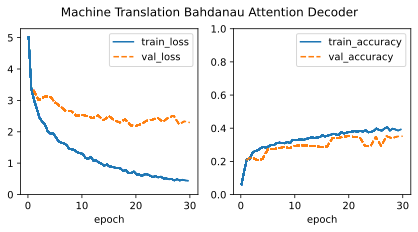

In [44]:
model = fit_mt(train_dl, val_dl, model, optimizer, loss_fn, num_epochs, 
       id="Machine Translation Bahdanau Attention Decoder", device=device);

#### Evaluation

In [45]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
arrays = build_mt(engs, fras, src_vocab, tgt_vocab)
preds, _ = model.to('cpu').predict_step(arrays, num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu: '
        f'{bleu(" ".join(translation), fr, k=2):.3f} '
        f'Target: {fr}')

go . => ['va', '!'], bleu: 1.000 Target: va !
i lost . => ['je', 'suis', 'perdu', '.'], bleu: 0.537 Target: j'ai perdu .
he's calm . => ['il', 'est', 'mouillé', '.'], bleu: 0.658 Target: il est calme .
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu: 1.000 Target: je suis chez moi .


#### Plot attention weights

In [46]:
_, dec_attention_weights = model.predict_step(
    build_mt(engs[-1:], fras[-1:], src_vocab, tgt_vocab), num_steps, True
)
enc_attention_weights = torch.stack(model.encoder.attention_weights, 0)
print(enc_attention_weights.shape)

torch.Size([2, 4, 9, 9])


In [47]:
print(engs[-1], fras[-1])
src, tgt, valid_len, tgt_label = build_mt(engs[-1:], fras[-1:], src_vocab, tgt_vocab)
print(src)
print(src_vocab.to_tokens(src[0]))
print(tgt)
print(tgt_vocab.to_tokens(tgt[0]))

i'm home . je suis chez moi .
tensor([[86, 76,  2,  3,  4,  4,  4,  4,  4]])
["i'm", 'home', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
tensor([[  3, 108, 183,  47, 129,   2,   4,   5,   5]])
['<bos>', 'je', 'suis', 'chez', 'moi', '.', '<eos>', '<pad>', '<pad>']


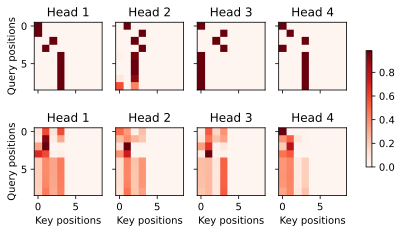

In [48]:
plt.close('all')
show_heatmaps(enc_attention_weights, 
              xlabel='Key positions', ylabel='Query positions', 
              titles=[f'Head {i}' for i in range(1, 5)], 
              figsize=(7, 3.5))

In [49]:
import pandas as pd
dec_attention_weights_2d = [head[0].tolist() for step in dec_attention_weights for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
print(dec_attention_weights_filled.shape)
dec_attention_weights_new = dec_attention_weights_filled.reshape(-1, 2, num_blks, num_heads, num_steps)
print(dec_attention_weights_new.shape)
dec_self_attention_weights, dec_inter_attention_weights = dec_attention_weights_new.permute(1, 2, 3, 0, 4)

print(dec_self_attention_weights.shape)
print(dec_inter_attention_weights.shape)

torch.Size([144, 9])
torch.Size([9, 2, 2, 4, 9])
torch.Size([2, 4, 9, 9])
torch.Size([2, 4, 9, 9])


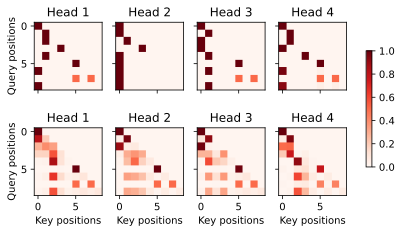

In [50]:
plt.close('all')
show_heatmaps(dec_self_attention_weights,
              xlabel='Key positions', ylabel='Query positions', 
              titles=[f'Head {i}' for i in range(1, 5)], 
              figsize=(7, 3.5))

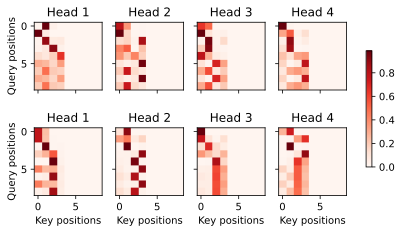

In [51]:
plt.close('all')
show_heatmaps(dec_inter_attention_weights,
              xlabel='Key positions', ylabel='Query positions', 
              titles=[f'Head {i}' for i in range(1, 5)], 
              figsize=(7, 3.5))